# Mesure dispersive du transmon

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import skrf as rf
from IPython.display import Image, display
from scipy.optimize import curve_fit
prop_cycle = rcParams['axes.prop_cycle']   
colors = prop_cycle.by_key()['color']
import scipy.constants as sc
from skrf import Frequency, Network

In [3]:
path_fig="..//Figures/" 
path_Sonnet="..//Sonnet/"

Nous allons simuler le circuit de mesure d'un transmon couplé à une cavité (circuit ci-dessous). Les parties colorées du schéma sont simulées à l'aide du logiciel Sonner EM.

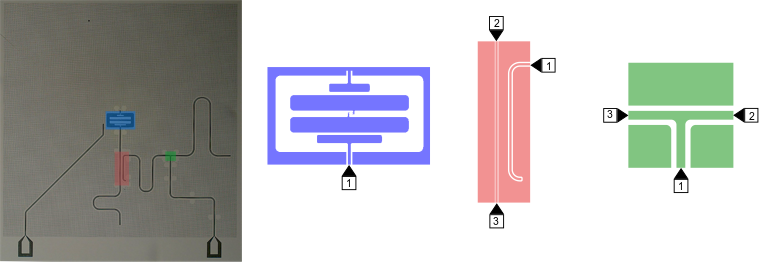

In [4]:
Image(filename=path_fig+"Simu_Board.png", width=800)

- Créer les éléments skrf correspondant aux fichiers:
    - <span style="color: blue;">Qubit_junction_g.s1p </span>   (couplage capacitif du qubit dans l'état $|0 \rangle$)
    - <span style="color: blue;">Qubit_junction_e.s1p </span>   (couplage capacitif du qubit dans l'état $|1 \rangle$)
    - <span style="color: red;">Qubit_coupler.s3p </span>   (coupleur à 3 port)
    - <span style="color: green;">Qubit_T_connection.s3p </span>  (jonction en T à 3 port)
- Créer des lignes de transmission skrf d'impédance caractéristique $Z_0= 54.93 \Omega$ et de vitesse de propagation $v_g=1.26 \times 10^8 \, \mathrm{m.s}^{-1}$. On utilisera les longueur des lignes mesurées au niveau des plans de référence utilisés dans les simulations Sonnet ainsi que la plage de fréquence des fichier s3p simulés en sonnet:
    - $L_{\mathrm{port-T}}=3939.5 \, \mu\mathrm{m}$
    - $L_{\mathrm{T-open}}= 5359.6 \, \mu\mathrm{m}$
    - $L_{\mathrm{coupler-T}}= 3398\, \mu\mathrm{m}$
    - $L_{\mathrm{coupler-capa}}=809.6 \, \mu\mathrm{m}$
    - $L_{\mathrm{coupler-short}}= 2888.6\, \mu\mathrm{m}$

- [Interpoler les fréquences](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.networkSet.NetworkSet.interpolate_frequency.html) de l'ensemble de ces structures,
- Créer 2 [ports](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Port.html), un [ground](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Ground.html) et un [open](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Open.html), 
états $|0\rangle$ et  $|1\rangle$,
- Créer 2 [connexions](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.connections_list.html)  simulant le qubit dans les états $|g \rangle$ et $|e \rangle$,
- Tracer la réponse en phase du résonanteur de lecture lorsque le qubit est respectivement dans l'état $|0 \rangle$ puis $|1 \rangle$,
- Déduire le shift dispersif $\chi$ et le comparer au couplage $\kappa_{\mathrm{c}}$ mesuré présédemment,
- Proposer une connexion permettant de voir l'effet du filtre Purcell.

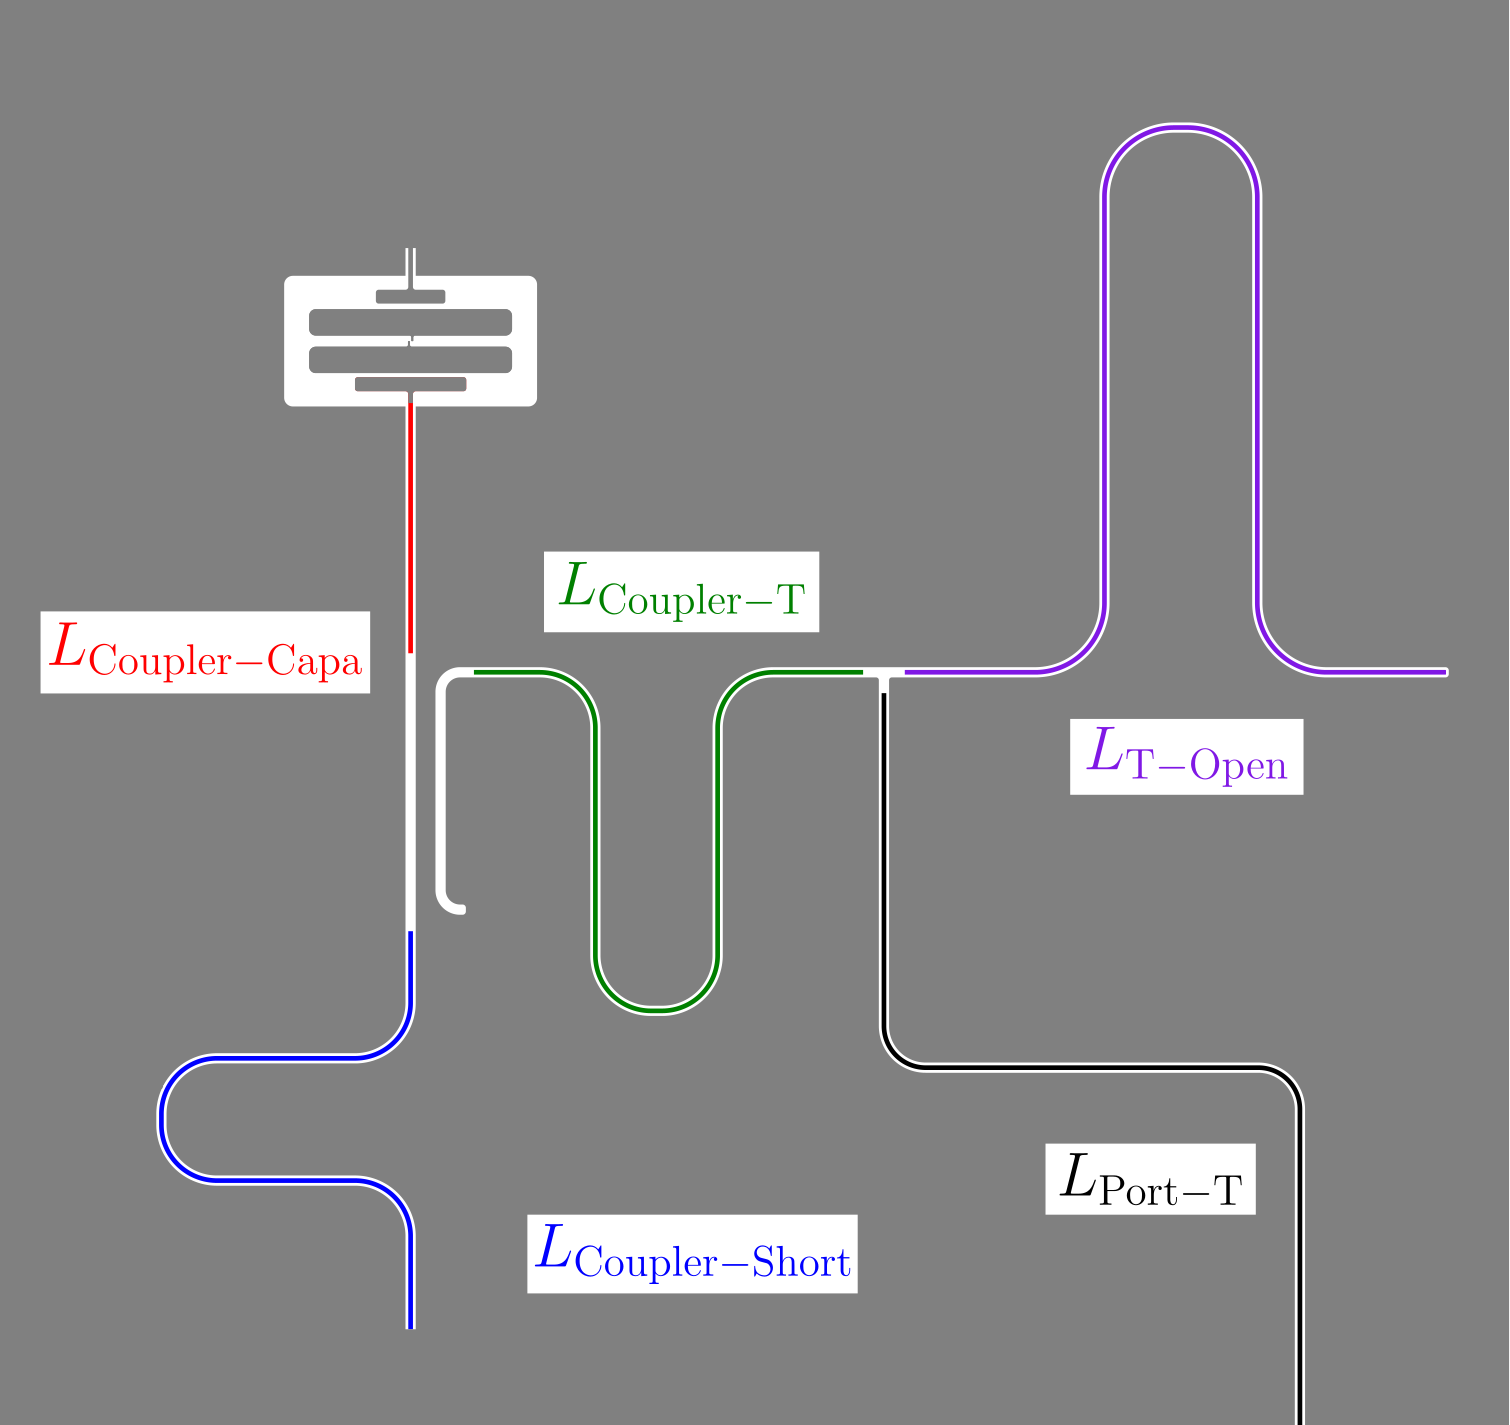

In [5]:
Image(filename=path_fig+"Longueur_transmon_lines.png", width=400)